# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 9_GSE114374_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/9_GSE114374.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
sc.settings.verbosity = 1
print(sc.__version__)

1.9.6


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 读取数据
GSE114374数据集：
- 结肠组织 基质细胞
- 2UC，2HC

In [3]:
adata = sc.read_h5ad('/Users/future/Nutstore Files/UC/scRNA-seq_data/02_sample_merge/9_GSE114374.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 9164 × 18216
    obs: 'n_genes', 'sample', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,n_genes,sample,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
AAACCTGCAAGGACTG-S66,2312,S66,GSM3140593,HC87,2774.336033,0.0,2312,0.833353,True,True,True,0.166452,False
AAACCTGCACAACTGT-S66,1133,S66,GSM3140593,HC87,2151.228692,0.0,1133,0.526676,True,True,True,0.010867,False
AAACCTGCACCCTATC-S66,1449,S66,GSM3140593,HC87,2298.312566,0.0,1449,0.630463,True,True,True,0.027778,False
AAACCTGCAGGCTCAC-S66,1272,S66,GSM3140593,HC87,2119.601536,0.0,1272,0.600113,True,True,True,0.019583,False
AAACCTGCAGTCTTCC-S66,1872,S66,GSM3140593,HC87,2583.274038,0.0,1872,0.724662,True,True,True,0.029301,False


## 处理细胞标签及分组

In [6]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                        id group
AAACCTGCAAGGACTG-S66  HC87    HC
AAACCTGCACAACTGT-S66  HC87    HC
AAACCTGCACCCTATC-S66  HC87    HC
AAACCTGCAGGCTCAC-S66  HC87    HC
AAACCTGCAGTCTTCC-S66  HC87    HC


`.obs`当中只保留GSM信息和分组信息

In [7]:
adata.obs.drop(columns=['sample', 'id'], inplace=True)
print(adata.obs.head())

                      n_genes         GSM        nUMIs  mito_perc  \
AAACCTGCAAGGACTG-S66     2312  GSM3140593  2774.336033        0.0   
AAACCTGCACAACTGT-S66     1133  GSM3140593  2151.228692        0.0   
AAACCTGCACCCTATC-S66     1449  GSM3140593  2298.312566        0.0   
AAACCTGCAGGCTCAC-S66     1272  GSM3140593  2119.601536        0.0   
AAACCTGCAGTCTTCC-S66     1872  GSM3140593  2583.274038        0.0   

                      detected_genes  cell_complexity  passing_mt  \
AAACCTGCAAGGACTG-S66            2312         0.833353        True   
AAACCTGCACAACTGT-S66            1133         0.526676        True   
AAACCTGCACCCTATC-S66            1449         0.630463        True   
AAACCTGCAGGCTCAC-S66            1272         0.600113        True   
AAACCTGCAGTCTTCC-S66            1872         0.724662        True   

                      passing_nUMIs  passing_ngenes  doublet_score  \
AAACCTGCAAGGACTG-S66           True            True       0.166452   
AAACCTGCACAACTGT-S66          

In [8]:
adata.obs['group'].value_counts()

group
UC    4844
HC    4320
Name: count, dtype: int64

## 样本质量查看

In [9]:
adata.obs['GSM'].value_counts()

GSM
GSM3140596    2780
GSM3140593    2440
GSM3140595    2064
GSM3140594    1880
Name: count, dtype: int64

In [10]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                                nUMIs              \
                   mean          std  min   max         mean         std   
GSM                                                                        
GSM3140593  1914.198361   650.244668  436  6280  2518.419155  485.667075   
GSM3140594  1740.417021   732.635753  353  8011  2342.330423  601.170784   
GSM3140595  2576.683624  1074.247548  391  7503  2922.159008  496.622725   
GSM3140596  2648.756475  1190.806594  697  8885  2868.396514  435.822109   

                                         mito_perc                           
                    min          max          mean       std  min       max  
GSM                                                                          
GSM3140593   714.608714  3835.848262  8.485491e-07  0.000016  0.0  0.000392  
GSM3140594   589.985222  3939.413257  5.935161e-07  0.000017  0.0  0.000598  
GSM3140595   809.755775  4223.429659  8.574230e-07  0.000017  0.0  0.000513  

/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_44030/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

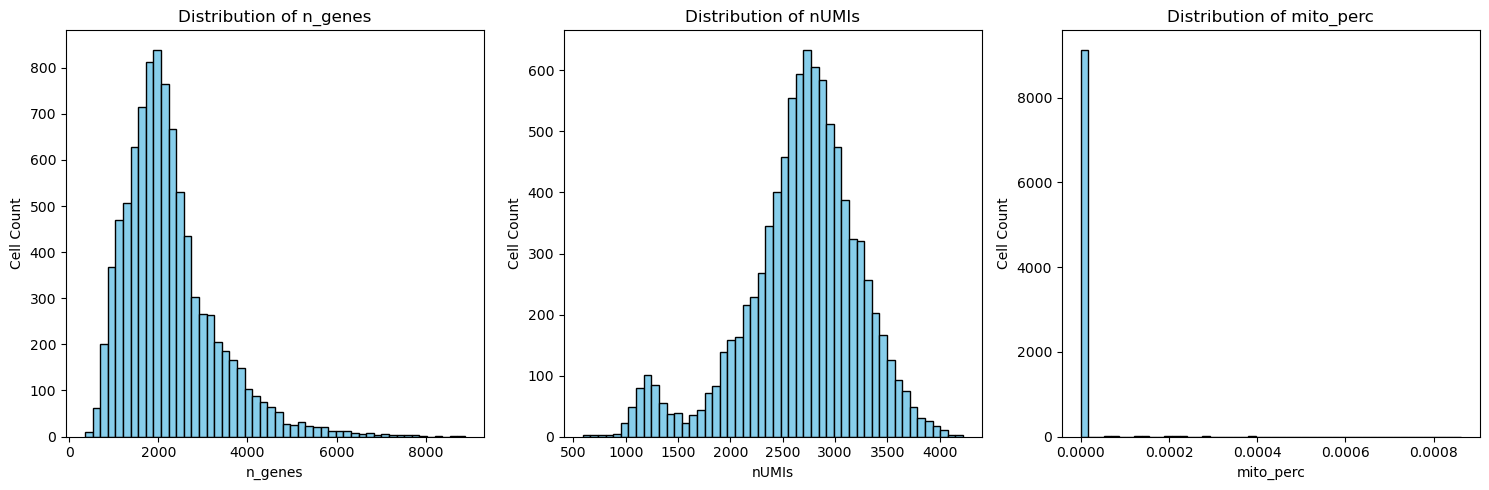

In [11]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_44030/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

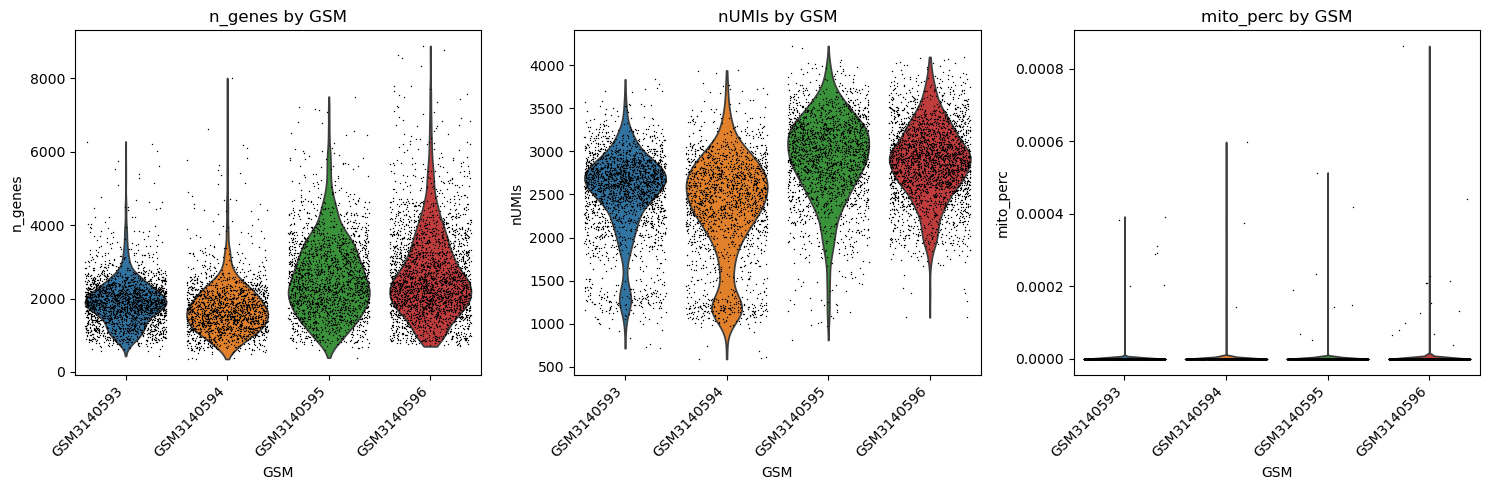

In [12]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 5000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [13]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 5000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 8962


## 保存质控后数据


In [14]:
import os
output_dir = "/Users/future/Nutstore Files/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "9_GSE114374_qc.h5ad"), compression='gzip')

## 降维聚类

In [ ]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

血液组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [ ]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [ ]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## GPT自动注释

In [ ]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

In [ ]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

In [ ]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [ ]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)